In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/seasonal_agriculture_performance_dataset.csv')

In [ ]:
df.head()


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [ ]:
df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,...,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,...,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,...,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,...,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,...,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [ ]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [ ]:
print(df.isnull().sum()[df.isnull().sum() > 0])

Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64


## Handling Missing values

In [ ]:
#Rainfall_mm
df["Rainfall_mm"] = df["Rainfall_mm"].fillna(
    df["Rainfall_mm"].median()
)

In [ ]:
#Soil_Moisture_pct
df["Soil_Moisture_pct"] = df["Soil_Moisture_pct"].fillna(
    df["Soil_Moisture_pct"].median()
)

In [ ]:
#Yield_Tonnes_Ha
df["Yield_Tonnes_Ha"] = df["Yield_Tonnes_Ha"].fillna(
    df.groupby(["Crop", "Season"])["Yield_Tonnes_Ha"]
      .transform("median")
)

In [ ]:
print("Missing values after treatment:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nTotal missing values:", df.isnull().sum().sum())

Missing values after treatment:
Series([], dtype: int64)

Total missing values: 0


# Handling Duplicates

In [ ]:
# Identify duplicate records
duplicates = df[df.duplicated(keep=False)]

# Display duplicate records
print("Duplicate Records:")
print(duplicates)

Duplicate Records:
Empty DataFrame
Columns: [Farm_ID, State, District, Crop, Season, Farm_Area_Hectares, Rainfall_mm, Avg_Temperature_C, Humidity_pct, Sunlight_Hours_Day, Soil_pH, Soil_Moisture_pct, Nitrogen_kg_ha, Phosphorus_kg_ha, Potassium_kg_ha, Irrigation_Method, Fertilizer_kg_ha, Pesticide_Litre_ha, Seed_Quality_Score, Yield_Tonnes_Ha, Production_Tonnes, Market_Price_INR_Tonne, Total_Cost_INR, Revenue_INR, Profit_INR, Water_Used_m3, Water_Efficiency_t_per_1000m3, Disease_Pest_Risk_pct]
Index: []

[0 rows x 28 columns]


# Statistical/Descriptive Analysis

In [ ]:
#Descriptive Analysis
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,4000.0,600.922825,287.193381,80.000,371.575,582.0000,831.97500,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,4000.0,26.507150,6.678837,8.000,21.800,26.4000,31.20000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


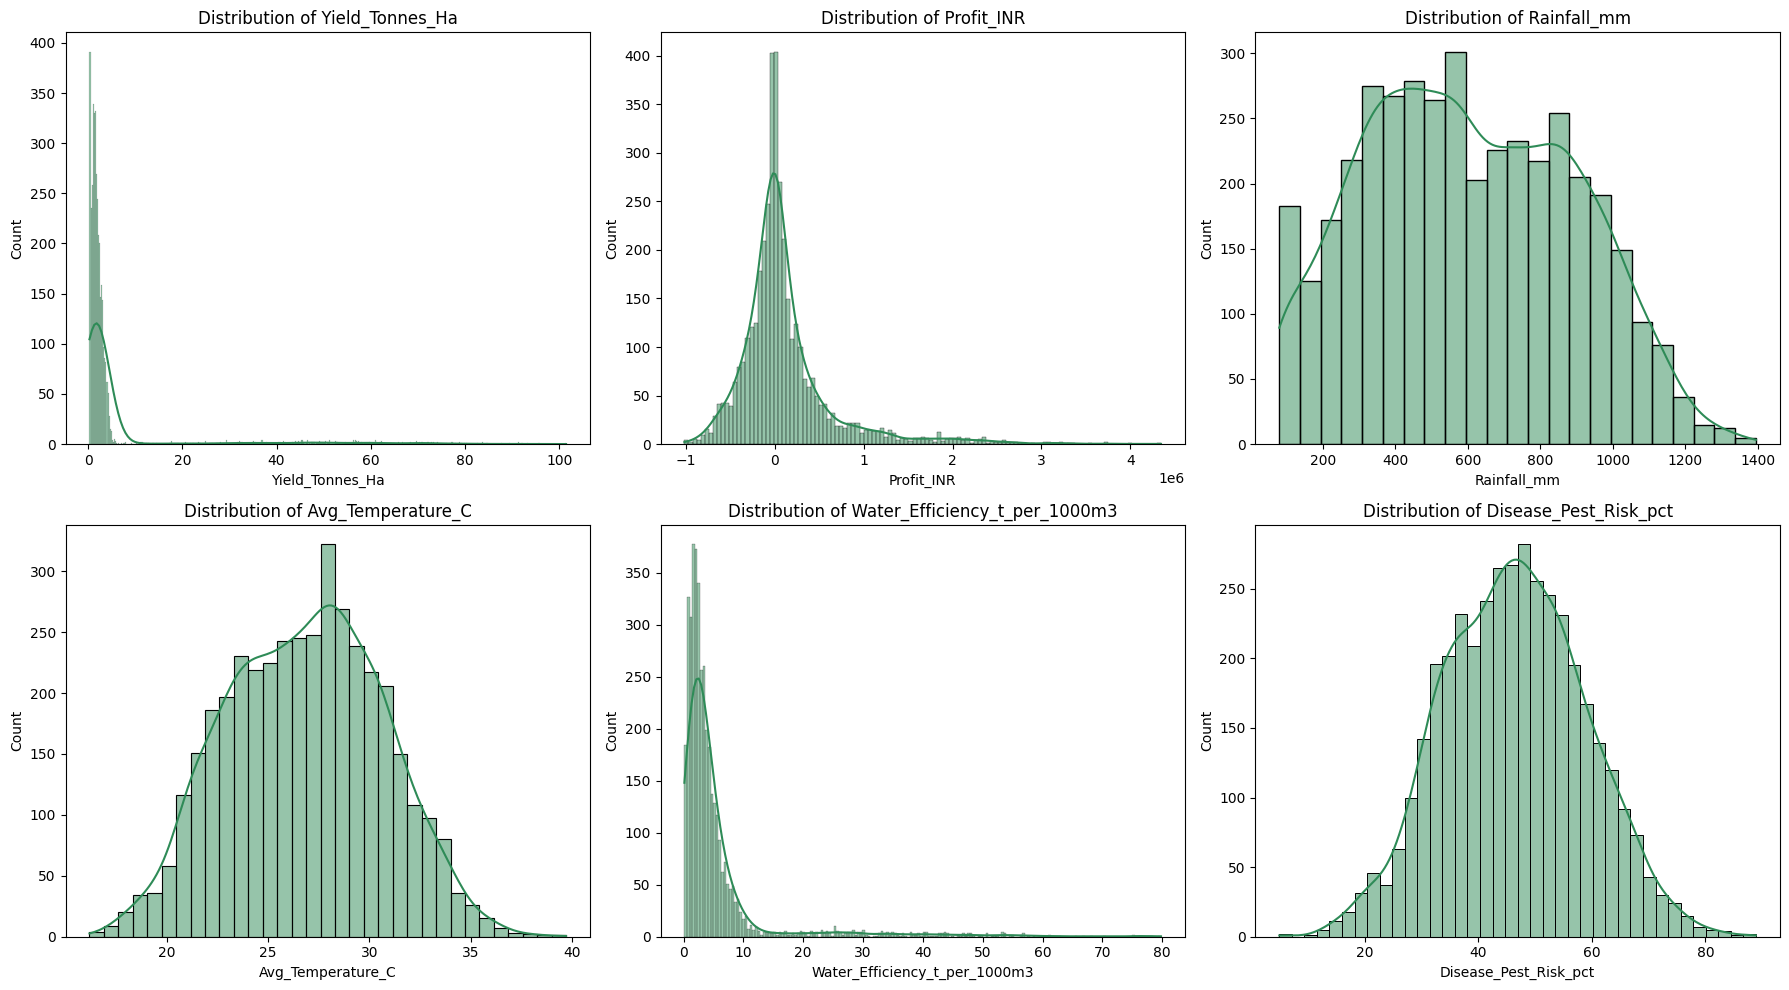

In [ ]:
plot_cols = ['Yield_Tonnes_Ha', 'Profit_INR', 'Rainfall_mm', 'Avg_Temperature_C',
             'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.flatten(), plot_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color='seagreen')
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.savefig('distributions.png', dpi=120)
plt.show()

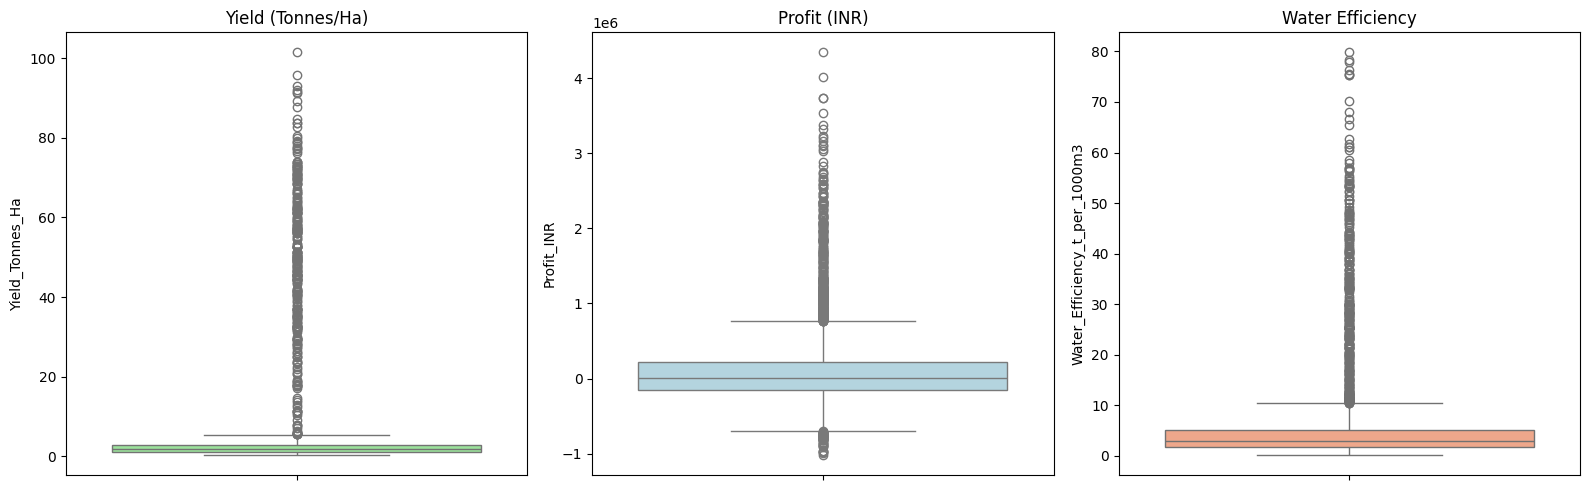

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.boxplot(y=df['Yield_Tonnes_Ha'], ax=axes[0], color='lightgreen')
axes[0].set_title('Yield (Tonnes/Ha)')
sns.boxplot(y=df['Profit_INR'], ax=axes[1], color='lightblue')
axes[1].set_title('Profit (INR)')
sns.boxplot(y=df['Water_Efficiency_t_per_1000m3'], ax=axes[2], color='lightsalmon')
axes[2].set_title('Water Efficiency')
plt.tight_layout()
plt.savefig('boxplots.png', dpi=120)
plt.show()

# Handling outliers

In [ ]:
#Outlier detection
crop_scaled_cols = ['Yield_Tonnes_Ha', 'Production_Tonnes', 'Revenue_INR',
                     'Total_Cost_INR', 'Profit_INR', 'Water_Used_m3',
                     'Water_Efficiency_t_per_1000m3']

def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

# Count outliers per crop per column (diagnostic only, no changes yet)
outlier_report = {}
for col in crop_scaled_cols:
    counts = {}
    for crop, grp in df.groupby('Crop'):
        lo, hi = iqr_bounds(grp[col].dropna())
        n_out = ((grp[col] < lo) | (grp[col] > hi)).sum()
        counts[crop] = n_out
    outlier_report[col] = counts

outlier_df = pd.DataFrame(outlier_report)
outlier_df.loc['TOTAL'] = outlier_df.sum()
print("Outlier counts by crop (IQR method, per-crop bounds):")
print(outlier_df)

Outlier counts by crop (IQR method, per-crop bounds):
           Yield_Tonnes_Ha  Production_Tonnes  Revenue_INR  Total_Cost_INR  \
Chilli                   1                  4            4               0   
Cotton                   1                  3            7               0   
Groundnut                0                  3            6               0   
Maize                    0                  3            4               0   
Pulses                   0                  7            6               0   
Rice                     0                  3            7               0   
Sugarcane                0                  2            3               0   
Wheat                    0                  6            5               0   
TOTAL                    2                 31           42               0   

           Profit_INR  Water_Used_m3  Water_Efficiency_t_per_1000m3  
Chilli             11              0                              1  
Cotton             29    

In [ ]:
env_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day',
            'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha',
            'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha',
            'Seed_Quality_Score', 'Disease_Pest_Risk_pct', 'Farm_Area_Hectares']

env_outlier_rows = []
for col in env_cols:
    lo, hi = iqr_bounds(df[col].dropna())
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    env_outlier_rows.append({'Column': col, 'Lower': round(lo, 2), 'Upper': round(hi, 2),
                              'Outliers': n_out, 'Pct': round(n_out / len(df) * 100, 2)})

env_outlier_df = pd.DataFrame(env_outlier_rows).sort_values('Outliers', ascending=False)
print(env_outlier_df.to_string(index=False))

               Column   Lower   Upper  Outliers  Pct
      Potassium_kg_ha   30.10  179.70        32 0.80
   Sunlight_Hours_Day    4.35   10.35        26 0.65
     Phosphorus_kg_ha   11.40  104.20        16 0.40
     Fertilizer_kg_ha   19.14  352.04        15 0.38
       Nitrogen_kg_ha   34.41  205.31        10 0.25
Disease_Pest_Risk_pct   10.90   81.30        10 0.25
   Pesticide_Litre_ha   -0.38   10.46         8 0.20
         Humidity_pct   29.09   97.59         6 0.15
    Soil_Moisture_pct    7.70   45.30         5 0.12
    Avg_Temperature_C   15.35   38.15         2 0.05
              Soil_pH    4.94    8.46         0 0.00
          Rainfall_mm -319.02 1522.57         0 0.00
   Seed_Quality_Score    0.48    1.17         0 0.00
   Farm_Area_Hectares   -6.83   22.73         0 0.00


Handling

In [ ]:
df_clean = df.copy()

# Cast columns that will be capped to float, since clipping can produce
# fractional bounds even if the original column was stored as int64.
for col in set(crop_scaled_cols + env_cols):
    df_clean[col] = df_clean[col].astype(float)

# (a) Crop-scaled metrics: cap using PER-CROP IQR bounds
for col in crop_scaled_cols:
    for crop, grp in df.groupby('Crop'):
        lo, hi = iqr_bounds(grp[col].dropna())
        idx = grp.index
        df_clean.loc[idx, col] = df_clean.loc[idx, col].clip(lower=lo, upper=hi)

# (b) Environmental metrics: cap using GLOBAL IQR bounds
for col in env_cols:
    lo, hi = iqr_bounds(df[col].dropna())
    df_clean[col] = df_clean[col].clip(lower=lo, upper=hi)

print("Capping complete.")
print(f"Rows affected in Yield_Tonnes_Ha:  {(df['Yield_Tonnes_Ha'] != df_clean['Yield_Tonnes_Ha']).sum()}")
print(f"Rows affected in Profit_INR:       {(df['Profit_INR'] != df_clean['Profit_INR']).sum()}")
print(f"Rows affected in Water_Used_m3:    {(df['Water_Used_m3'] != df_clean['Water_Used_m3']).sum()}")

Capping complete.
Rows affected in Yield_Tonnes_Ha:  2
Rows affected in Profit_INR:       201
Rows affected in Water_Used_m3:    5


Before and after

In [ ]:
compare_cols = ['Yield_Tonnes_Ha', 'Profit_INR', 'Water_Efficiency_t_per_1000m3', 'Water_Used_m3']
before = df[compare_cols].describe().T[['mean', 'std', 'min', 'max']].add_suffix('_before')
after = df_clean[compare_cols].describe().T[['mean', 'std', 'min', 'max']].add_suffix('_after')
comparison = pd.concat([before, after], axis=1).round(2)
comparison = comparison[sorted(comparison.columns)]
print(comparison)

                                max_after  max_before  mean_after  \
Yield_Tonnes_Ha                    101.44      101.44        5.27   
Profit_INR                     2906167.00  4345421.00   109503.74   
Water_Efficiency_t_per_1000m3       72.90       79.80        5.37   
Water_Used_m3                    38888.50    40902.00     6043.15   

                               mean_before  min_after  min_before  std_after  \
Yield_Tonnes_Ha                       5.27       0.30        0.30      13.34   
Profit_INR                       111556.46 -724843.00 -1019223.00  524884.79   
Water_Efficiency_t_per_1000m3         5.39       0.14        0.14       8.78   
Water_Used_m3                      6045.57     128.00      128.00    5566.47   

                               std_before  
Yield_Tonnes_Ha                     13.34  
Profit_INR                      545081.89  
Water_Efficiency_t_per_1000m3        8.84  
Water_Used_m3                     5572.94  


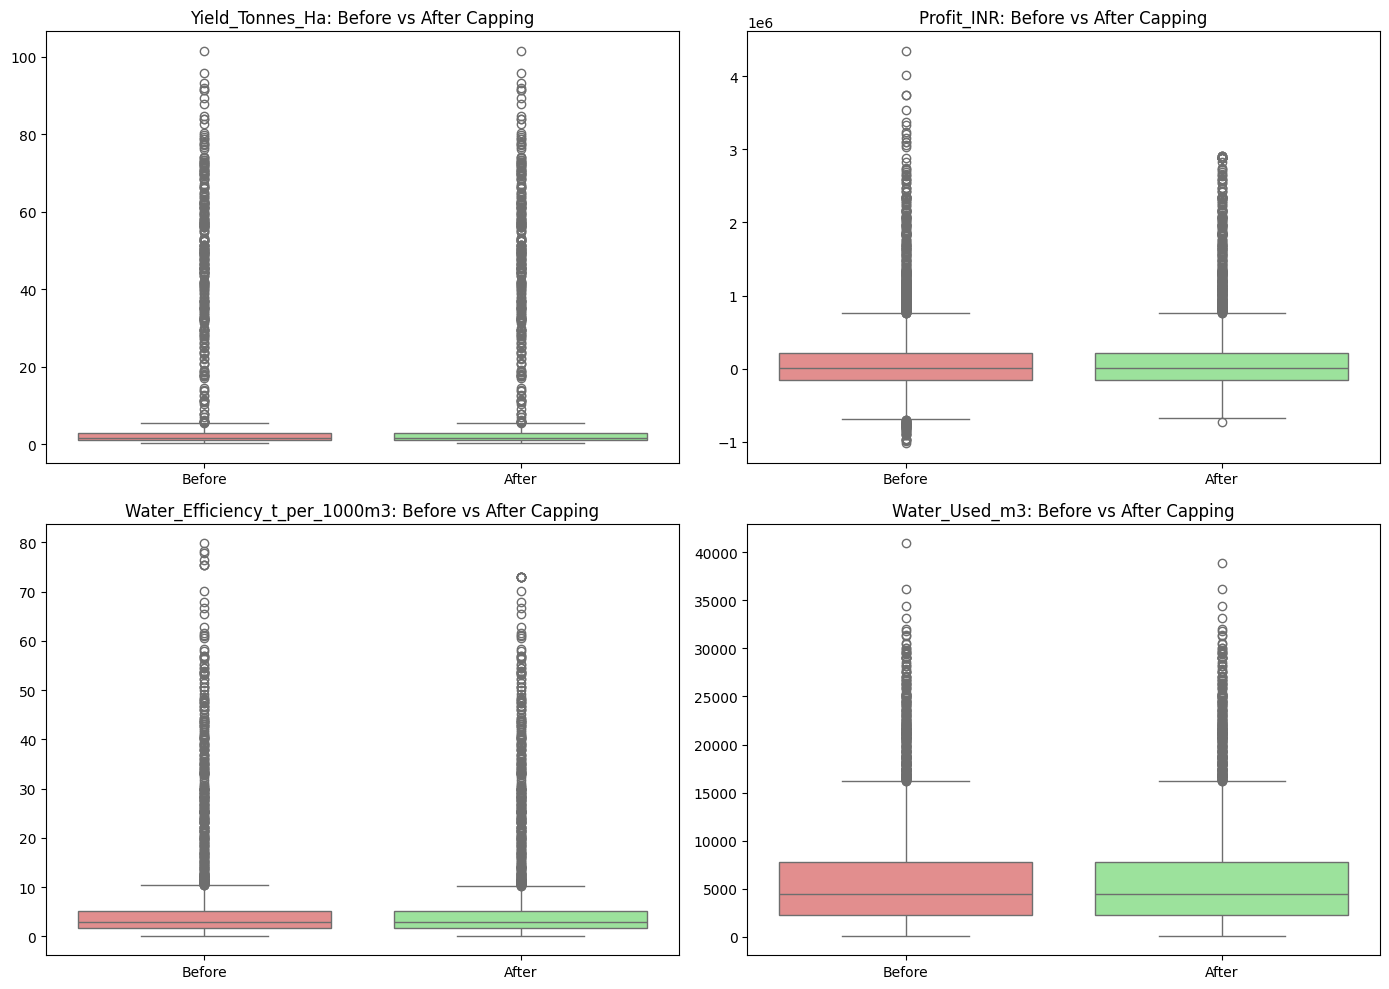

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flatten(), compare_cols):
    plot_data = pd.DataFrame({
        'Before': df[col],
        'After': df_clean[col]
    })
    sns.boxplot(data=plot_data, ax=ax, palette=['lightcoral', 'lightgreen'])
    ax.set_title(f'{col}: Before vs After Capping')

plt.tight_layout()
plt.savefig('outliers_before_after.png', dpi=120)
plt.show()

# Univariate Analysis

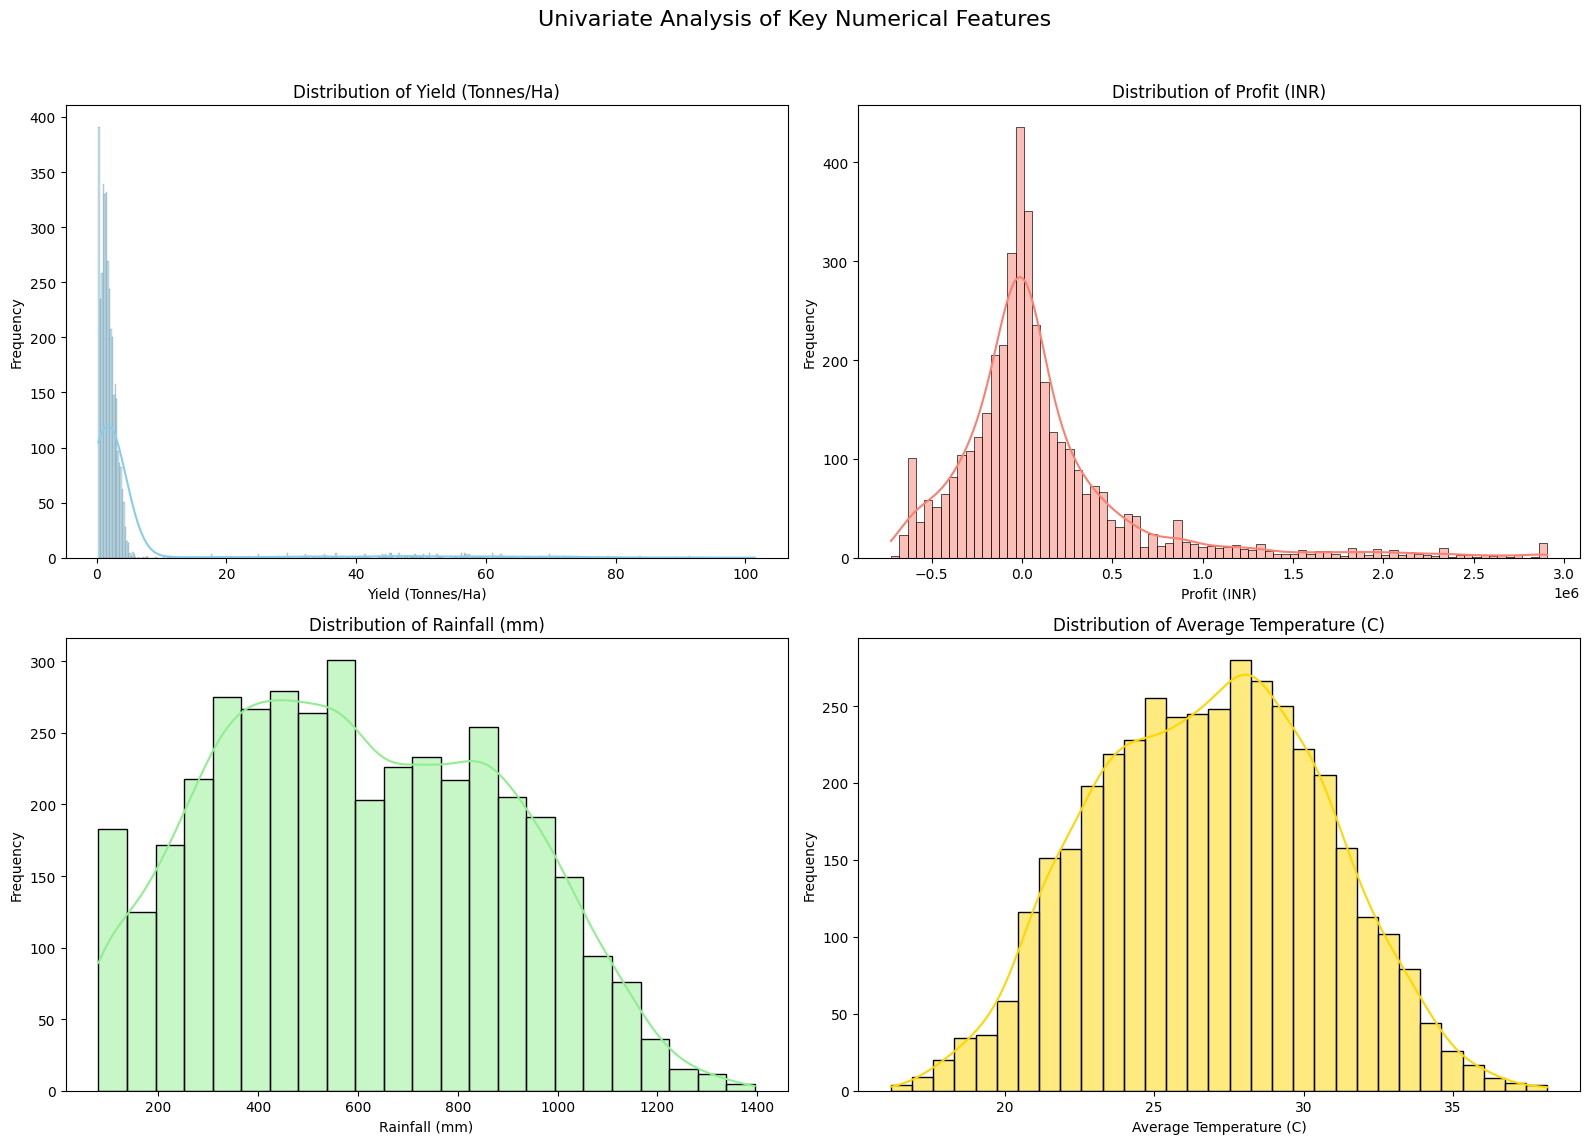


Descriptive statistics for key numerical features:
                    count           mean            std       min         25%  \
Yield_Tonnes_Ha    4000.0       5.265175      13.341532       0.3       1.050   
Profit_INR         4000.0  109503.738500  524884.788747 -724843.0 -148731.750   
Rainfall_mm        4000.0     600.922825     287.193381      80.0     371.575   
Avg_Temperature_C  4000.0      26.818450       3.816763      16.2      23.900   

                       50%         75%         max  
Yield_Tonnes_Ha       1.74       2.840      101.44  
Profit_INR         3673.00  216187.750  2906167.00  
Rainfall_mm         582.00     831.975     1395.20  
Avg_Temperature_C    26.90      29.600       38.15  


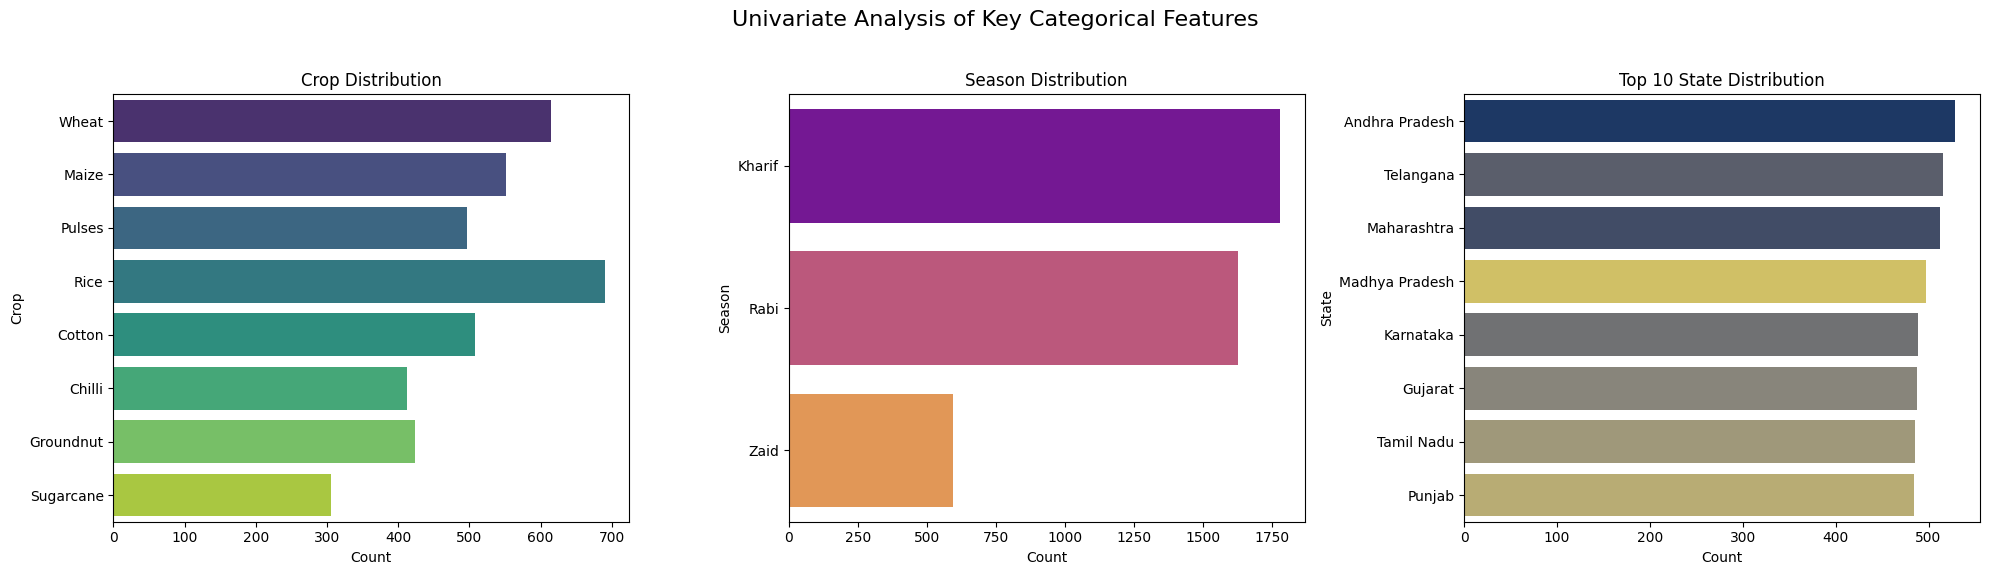

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Univariate analysis for numerical features
# Set up the matplotlib figure and axes
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Univariate Analysis of Key Numerical Features', fontsize=16)

# Yield_Tonnes_Ha
sns.histplot(df_clean['Yield_Tonnes_Ha'], kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Distribution of Yield (Tonnes/Ha)')
axes[0, 0].set_xlabel('Yield (Tonnes/Ha)')
axes[0, 0].set_ylabel('Frequency')

# Profit_INR
sns.histplot(df_clean['Profit_INR'], kde=True, ax=axes[0, 1], color='salmon')
axes[0, 1].set_title('Distribution of Profit (INR)')
axes[0, 1].set_xlabel('Profit (INR)')
axes[0, 1].set_ylabel('Frequency')

# Rainfall_mm
sns.histplot(df_clean['Rainfall_mm'], kde=True, ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Distribution of Rainfall (mm)')
axes[1, 0].set_xlabel('Rainfall (mm)')
axes[1, 0].set_ylabel('Frequency')

# Avg_Temperature_C
sns.histplot(df_clean['Avg_Temperature_C'], kde=True, ax=axes[1, 1], color='gold')
axes[1, 1].set_title('Distribution of Average Temperature (C)')
axes[1, 1].set_xlabel('Average Temperature (C)')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.savefig('numerical_univariate_analysis.png', dpi=120)
plt.show()

print("\nDescriptive statistics for key numerical features:")
print(df_clean[['Yield_Tonnes_Ha', 'Profit_INR', 'Rainfall_mm', 'Avg_Temperature_C']].describe().T)

# Univariate analysis for categorical features
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Univariate Analysis of Key Categorical Features', fontsize=16)

# Crop
sns.countplot(y=df_clean['Crop'], ax=axes[0], palette='viridis', hue=df_clean['Crop'], legend=False)
axes[0].set_title('Crop Distribution')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Crop')

# Season
sns.countplot(y=df_clean['Season'], ax=axes[1], palette='plasma', hue=df_clean['Season'], legend=False)
axes[1].set_title('Season Distribution')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('Season')

# State (top 10 for better readability)
top_states = df_clean['State'].value_counts().nlargest(10).index
sns.countplot(y=df_clean[df_clean['State'].isin(top_states)]['State'], ax=axes[2], palette='cividis', order=top_states, hue=df_clean[df_clean['State'].isin(top_states)]['State'], legend=False)
axes[2].set_title('Top 10 State Distribution')
axes[2].set_xlabel('Count')
axes[2].set_ylabel('State')

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.savefig('categorical_univariate_analysis.png', dpi=120)
plt.show()


## Bivariate Analysis

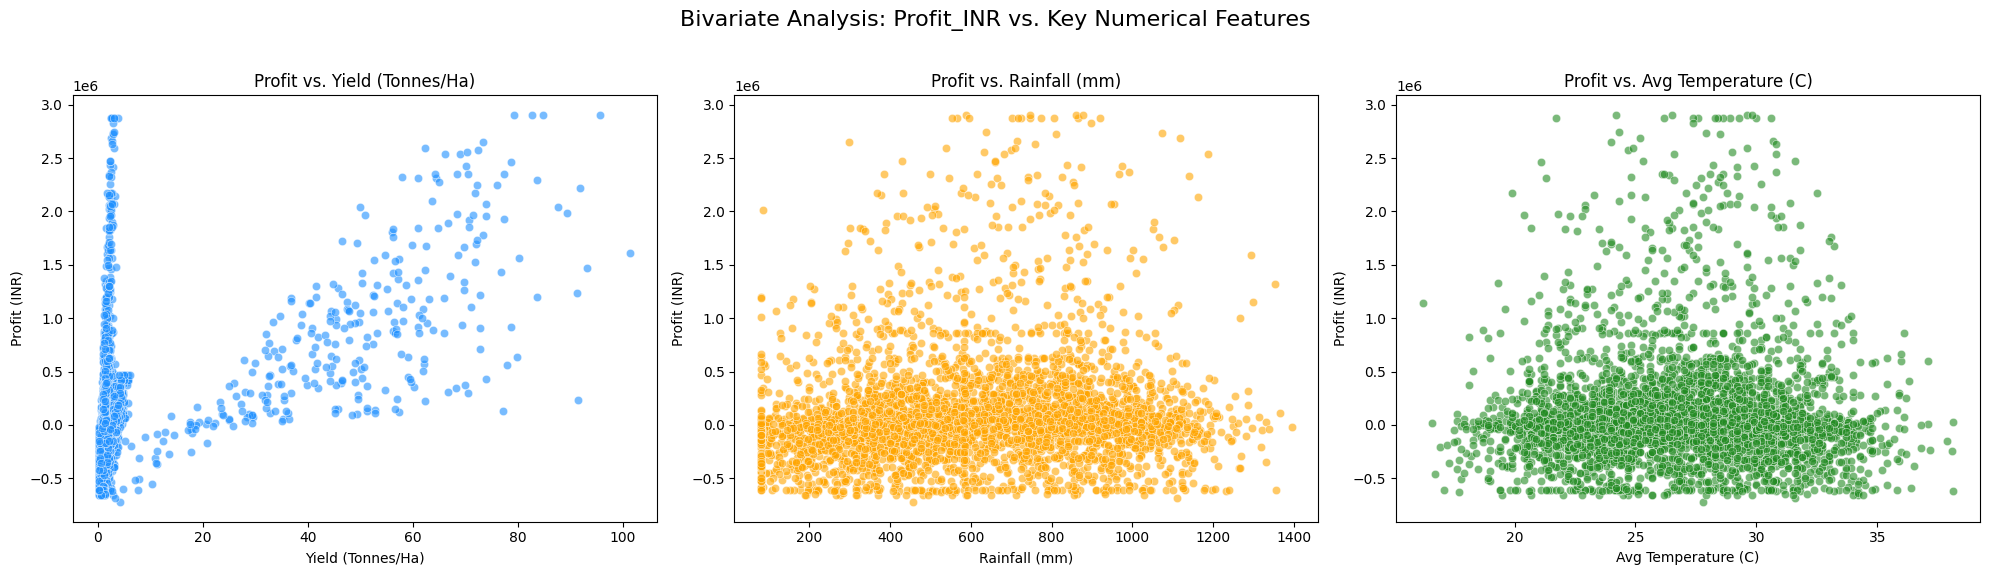

In [ ]:
# Bivariate analysis: Numerical vs. Numerical (Scatter Plots)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Bivariate Analysis: Profit_INR vs. Key Numerical Features', fontsize=16)

# Profit_INR vs. Yield_Tonnes_Ha
sns.scatterplot(x='Yield_Tonnes_Ha', y='Profit_INR', data=df_clean, ax=axes[0], alpha=0.6, color='dodgerblue')
axes[0].set_title('Profit vs. Yield (Tonnes/Ha)')
axes[0].set_xlabel('Yield (Tonnes/Ha)')
axes[0].set_ylabel('Profit (INR)')

# Profit_INR vs. Rainfall_mm
sns.scatterplot(x='Rainfall_mm', y='Profit_INR', data=df_clean, ax=axes[1], alpha=0.6, color='orange')
axes[1].set_title('Profit vs. Rainfall (mm)')
axes[1].set_xlabel('Rainfall (mm)')
axes[1].set_ylabel('Profit (INR)')

# Profit_INR vs. Avg_Temperature_C
sns.scatterplot(x='Avg_Temperature_C', y='Profit_INR', data=df_clean, ax=axes[2], alpha=0.6, color='forestgreen')
axes[2].set_title('Profit vs. Avg Temperature (C)')
axes[2].set_xlabel('Avg Temperature (C)')
axes[2].set_ylabel('Profit (INR)')

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.savefig('numerical_bivariate_analysis.png', dpi=120)
plt.show()


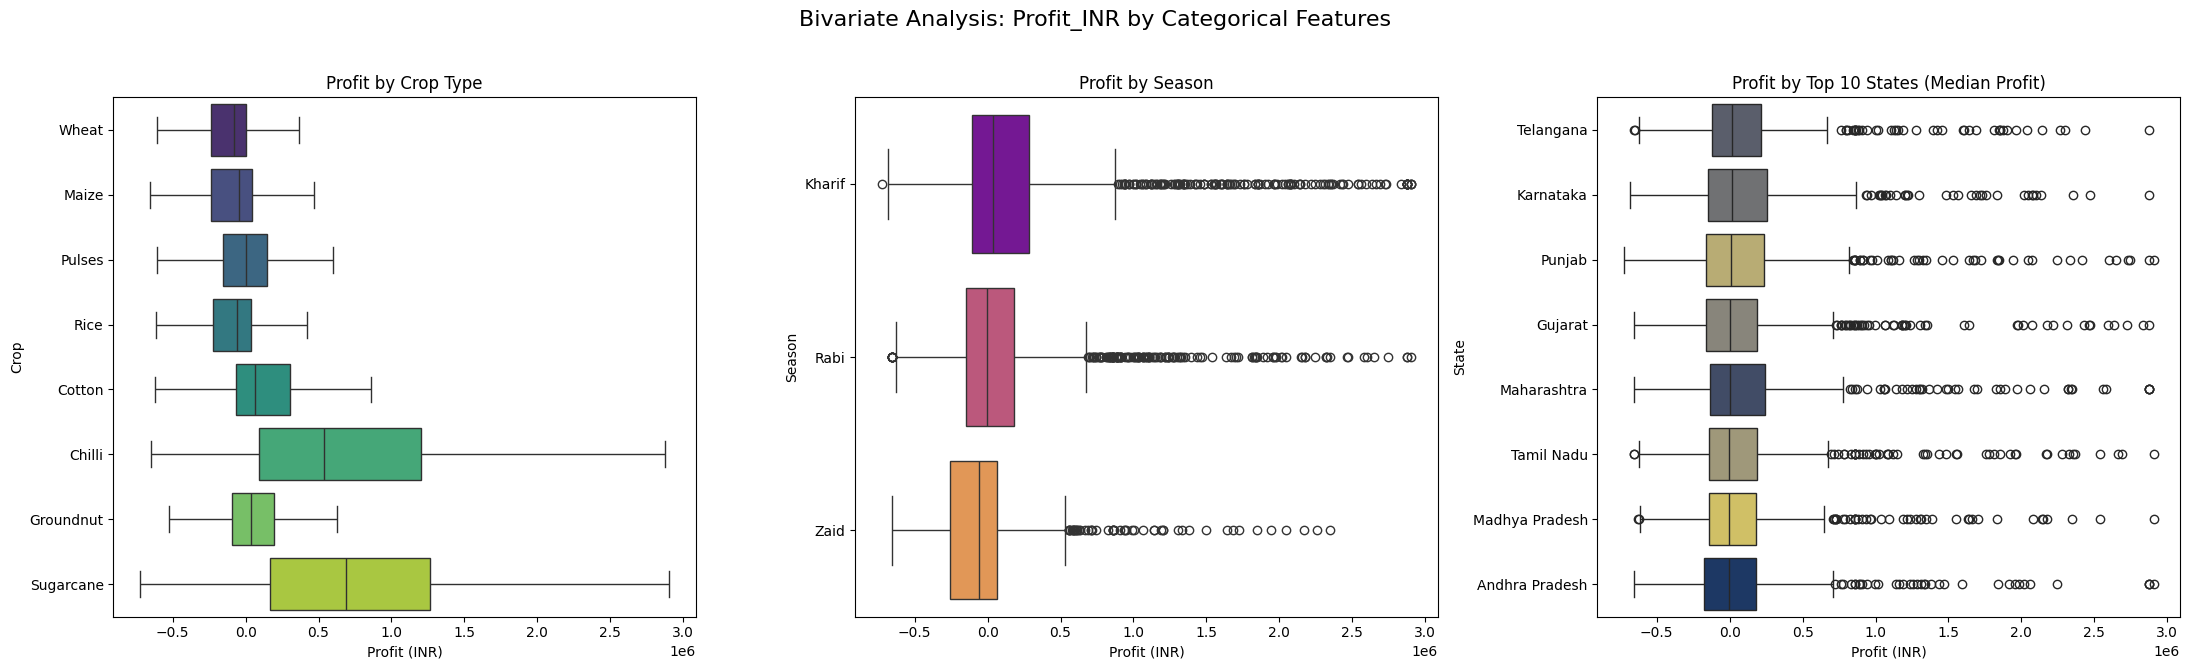

In [ ]:
# Bivariate analysis: Numerical vs. Categorical (Box Plots)

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Bivariate Analysis: Profit_INR by Categorical Features', fontsize=16)

# Profit_INR vs. Crop
sns.boxplot(x='Profit_INR', y='Crop', data=df_clean, ax=axes[0], palette='viridis', hue='Crop', legend=False)
axes[0].set_title('Profit by Crop Type')
axes[0].set_xlabel('Profit (INR)')
axes[0].set_ylabel('Crop')

# Profit_INR vs. Season
sns.boxplot(x='Profit_INR', y='Season', data=df_clean, ax=axes[1], palette='plasma', hue='Season', legend=False)
axes[1].set_title('Profit by Season')
axes[1].set_xlabel('Profit (INR)')
axes[1].set_ylabel('Season')

# Profit_INR vs. State (Top 10 states by profit median)
top_10_states = df_clean.groupby('State')['Profit_INR'].median().nlargest(10).index
sns.boxplot(x='Profit_INR', y='State', data=df_clean[df_clean['State'].isin(top_10_states)], ax=axes[2], palette='cividis', order=top_10_states, hue='State', legend=False)
axes[2].set_title('Profit by Top 10 States (Median Profit)')
axes[2].set_xlabel('Profit (INR)')
axes[2].set_ylabel('State')

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.savefig('categorical_bivariate_analysis.png', dpi=120)
plt.show()


## Multivariate Analysis

### Correlation Matrix Heatmap



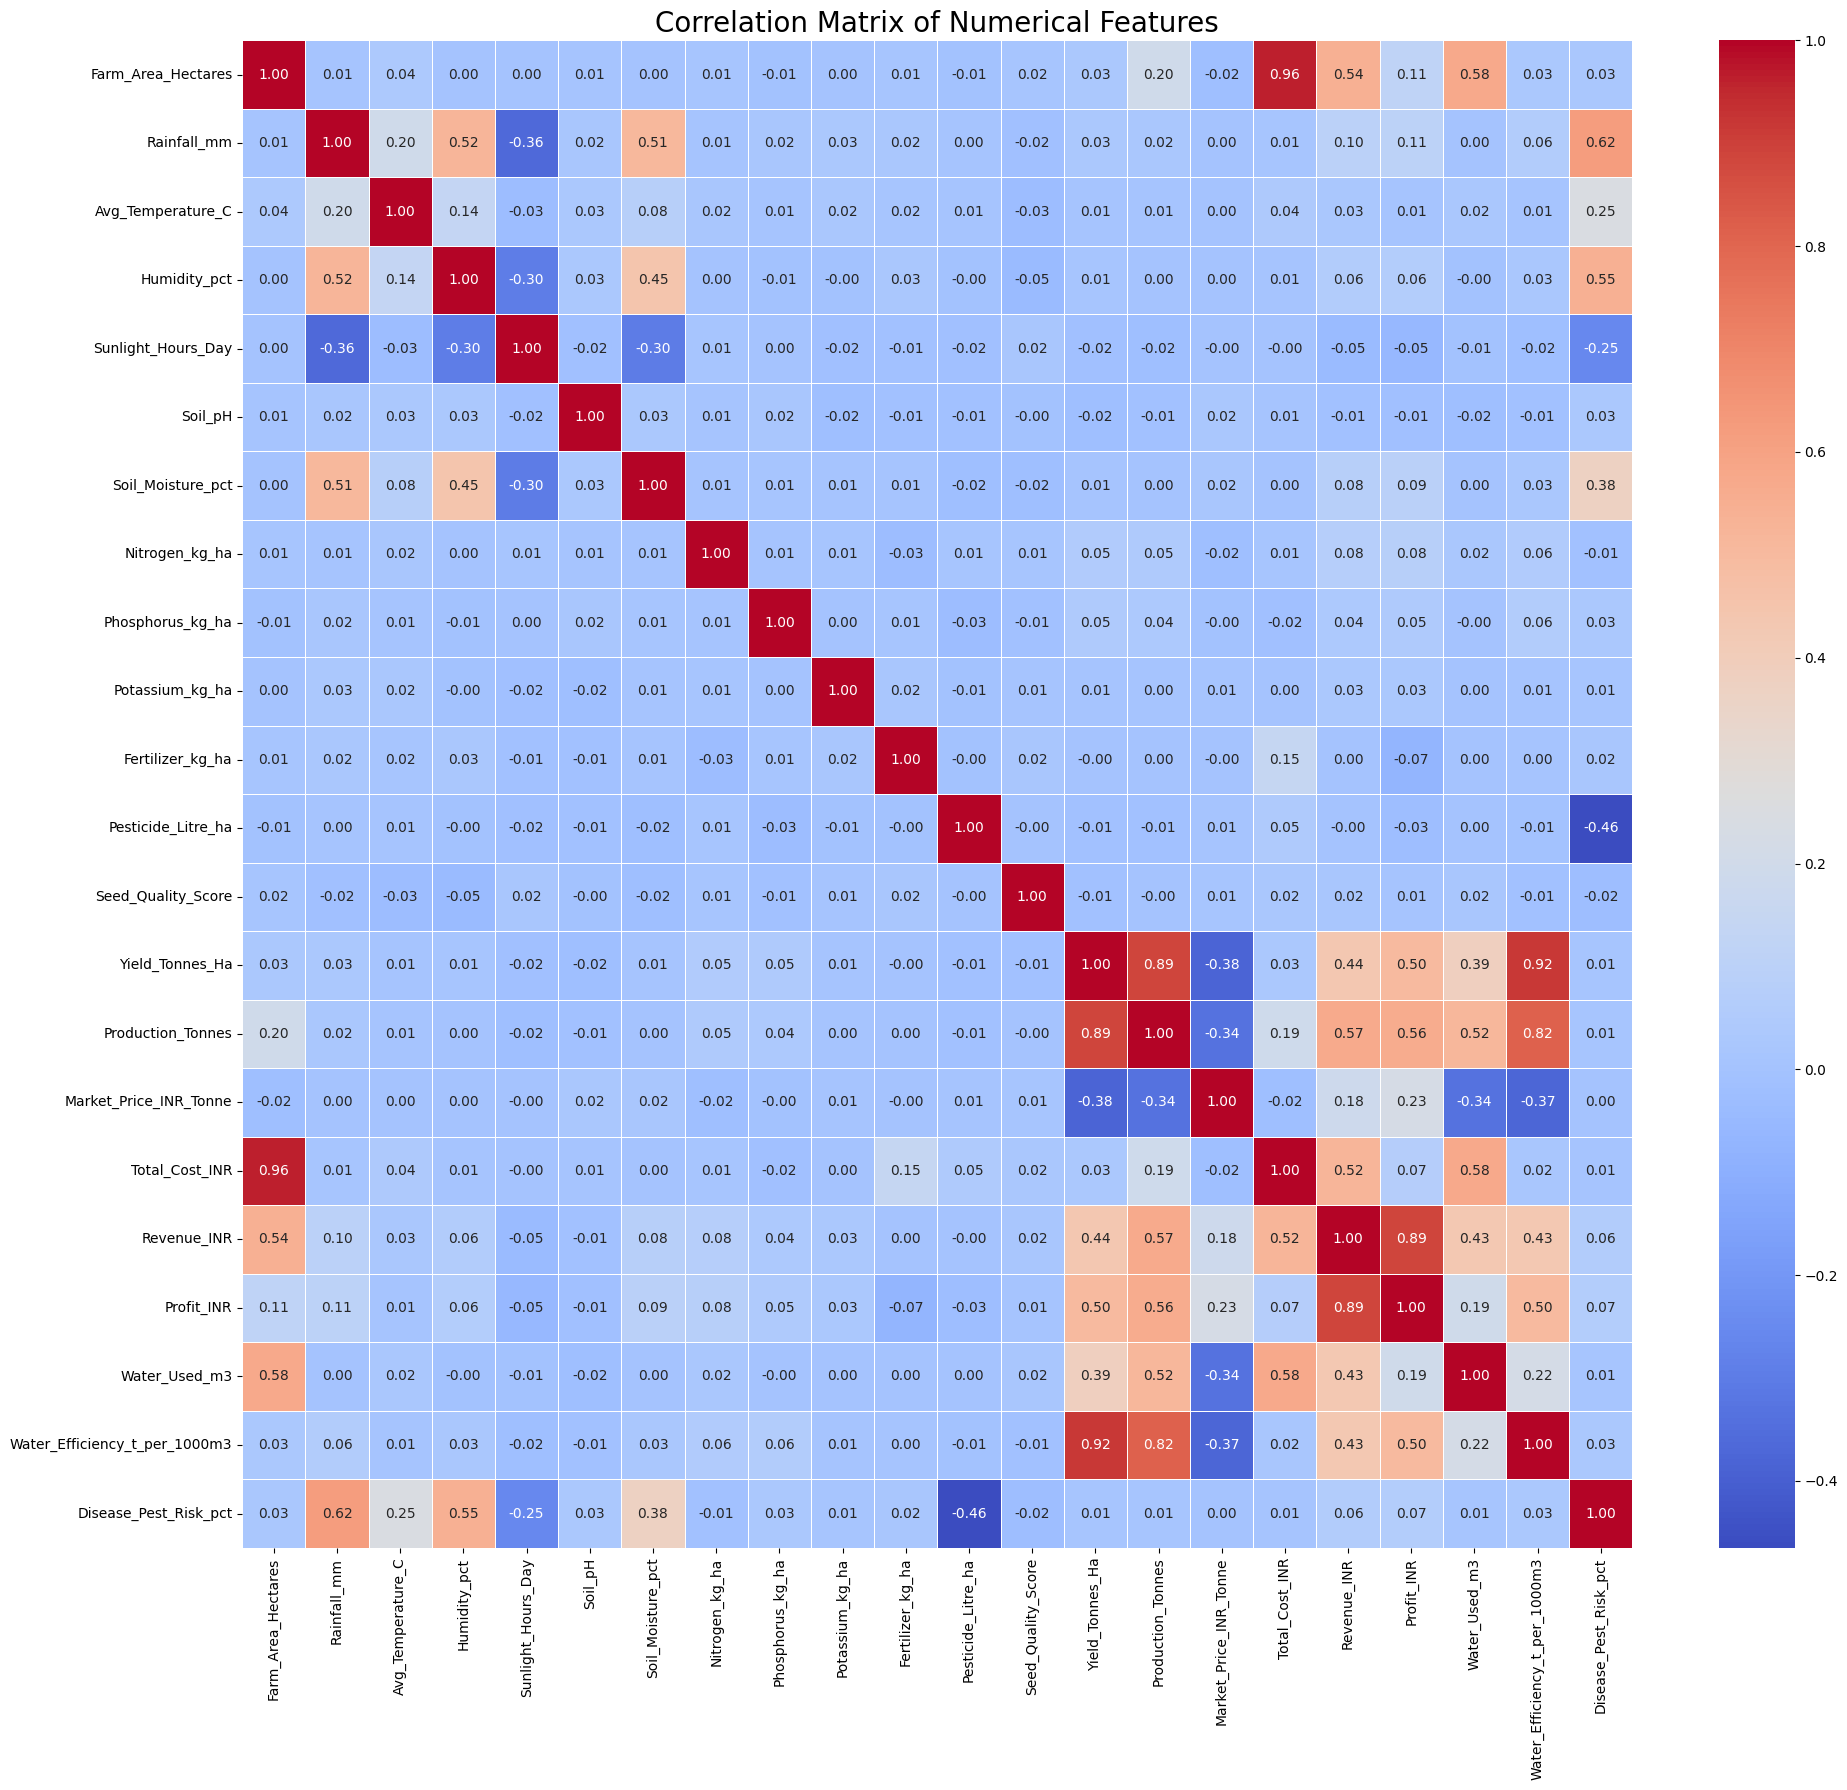

In [25]:
# Select only numerical columns for correlation analysis
numerical_cols = df_clean.select_dtypes(include=np.number).columns
correlation_matrix = df_clean[numerical_cols].corr()

# Plotting the heatmap
plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=120)
plt.show()

## Seasonal Comparisons

To understand the impact of different seasons on agricultural performance, we will visualize the distribution of key metrics such as `Yield_Tonnes_Ha`, `Profit_INR`, `Rainfall_mm`, and `Avg_Temperature_C` across the various seasons present in the dataset.

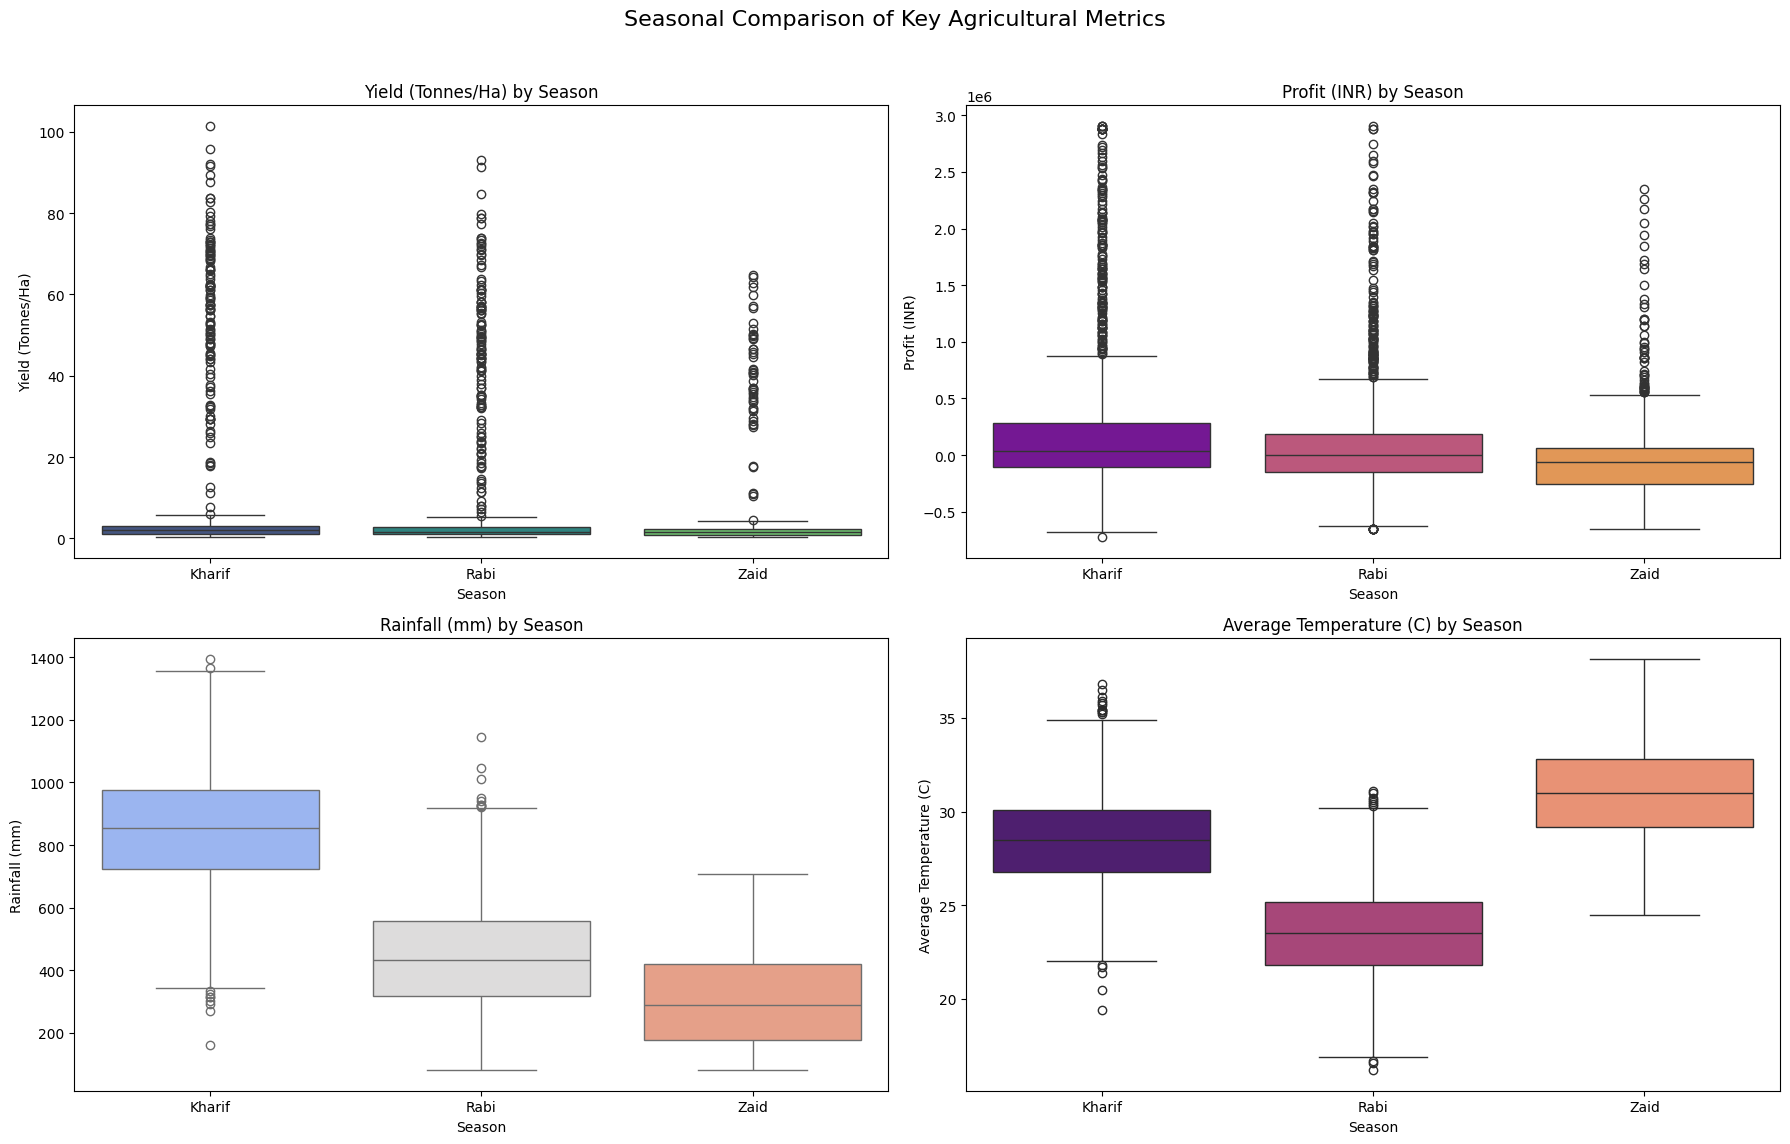

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Seasonal Comparison of Key Agricultural Metrics', fontsize=16)

# Yield by Season
sns.boxplot(x='Season', y='Yield_Tonnes_Ha', data=df_clean, ax=axes[0, 0], palette='viridis', hue='Season', legend=False)
axes[0, 0].set_title('Yield (Tonnes/Ha) by Season')
axes[0, 0].set_xlabel('Season')
axes[0, 0].set_ylabel('Yield (Tonnes/Ha)')

# Profit by Season
sns.boxplot(x='Season', y='Profit_INR', data=df_clean, ax=axes[0, 1], palette='plasma', hue='Season', legend=False)
axes[0, 1].set_title('Profit (INR) by Season')
axes[0, 1].set_xlabel('Season')
axes[0, 1].set_ylabel('Profit (INR)')

# Rainfall by Season
sns.boxplot(x='Season', y='Rainfall_mm', data=df_clean, ax=axes[1, 0], palette='coolwarm', hue='Season', legend=False)
axes[1, 0].set_title('Rainfall (mm) by Season')
axes[1, 0].set_xlabel('Season')
axes[1, 0].set_ylabel('Rainfall (mm)')

# Average Temperature by Season
sns.boxplot(x='Season', y='Avg_Temperature_C', data=df_clean, ax=axes[1, 1], palette='magma', hue='Season', legend=False)
axes[1, 1].set_title('Average Temperature (C) by Season')
axes[1, 1].set_xlabel('Season')
axes[1, 1].set_ylabel('Average Temperature (C)')

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.savefig('seasonal_comparisons.png', dpi=120)
plt.show()

## Student-Designed Analysis 1: Crop-wise Performance Comparison

This analysis aims to understand how different crops compare in terms of key performance indicators like `Yield_Tonnes_Ha` and `Profit_INR`. We will use box plots to visualize the distribution of these metrics for each crop, providing insights into average performance and variability.

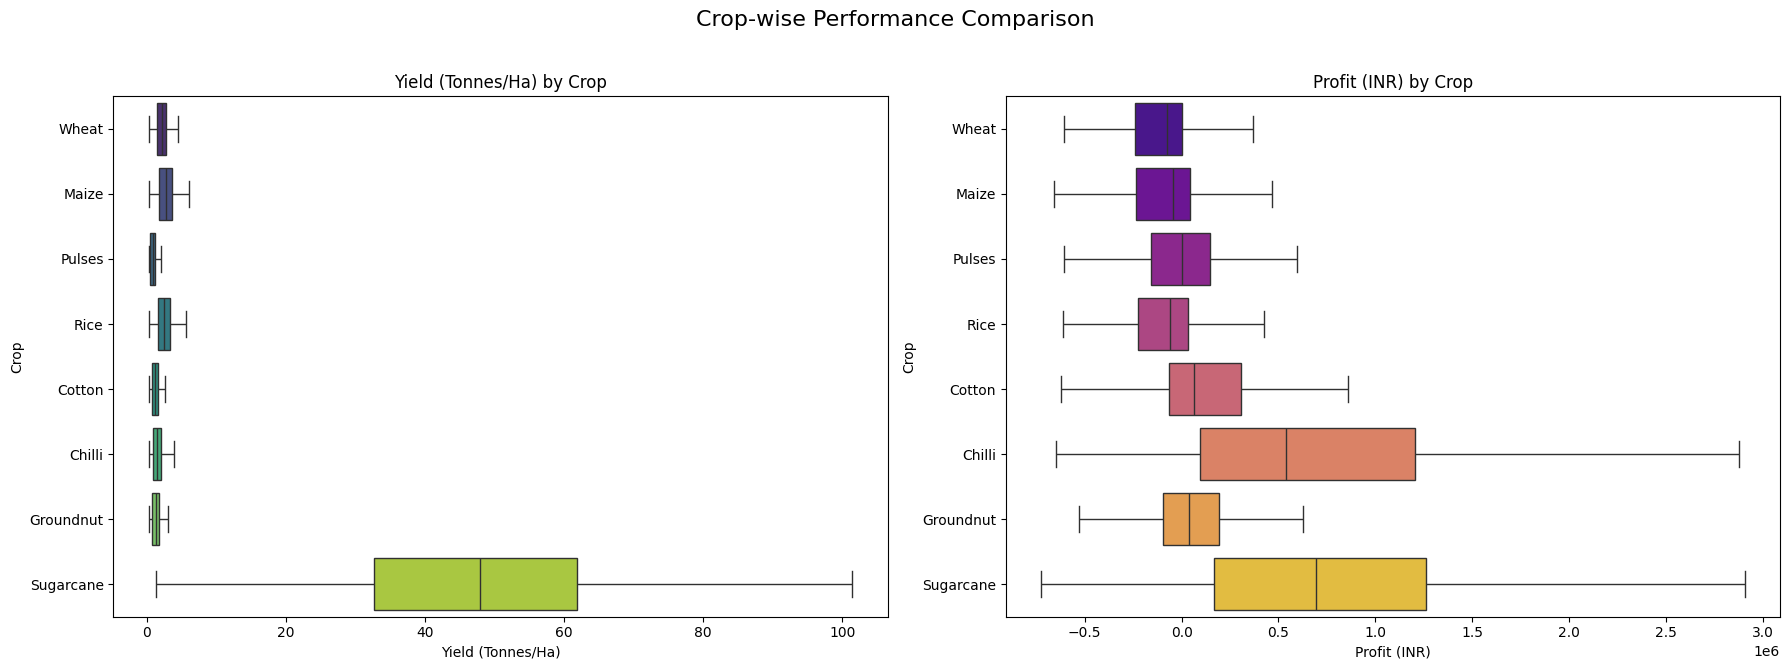

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Crop-wise Performance Comparison', fontsize=16)

# Yield_Tonnes_Ha by Crop
sns.boxplot(x='Yield_Tonnes_Ha', y='Crop', data=df_clean, ax=axes[0], palette='viridis', hue='Crop', legend=False)
axes[0].set_title('Yield (Tonnes/Ha) by Crop')
axes[0].set_xlabel('Yield (Tonnes/Ha)')
axes[0].set_ylabel('Crop')

# Profit_INR by Crop
sns.boxplot(x='Profit_INR', y='Crop', data=df_clean, ax=axes[1], palette='plasma', hue='Crop', legend=False)
axes[1].set_title('Profit (INR) by Crop')
axes[1].set_xlabel('Profit (INR)')
axes[1].set_ylabel('Crop')

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.savefig('crop_performance_comparison.png', dpi=120)
plt.show()

## Student-Designed Analysis 2: Impact of Soil Nutrients on Yield

This analysis investigates the relationship between key soil nutrients (`Nitrogen_kg_ha`, `Phosphorus_kg_ha`, `Potassium_kg_ha`) and `Yield_Tonnes_Ha`. We will use scatter plots to visualize these relationships, which can help in understanding optimal nutrient levels for better yields.

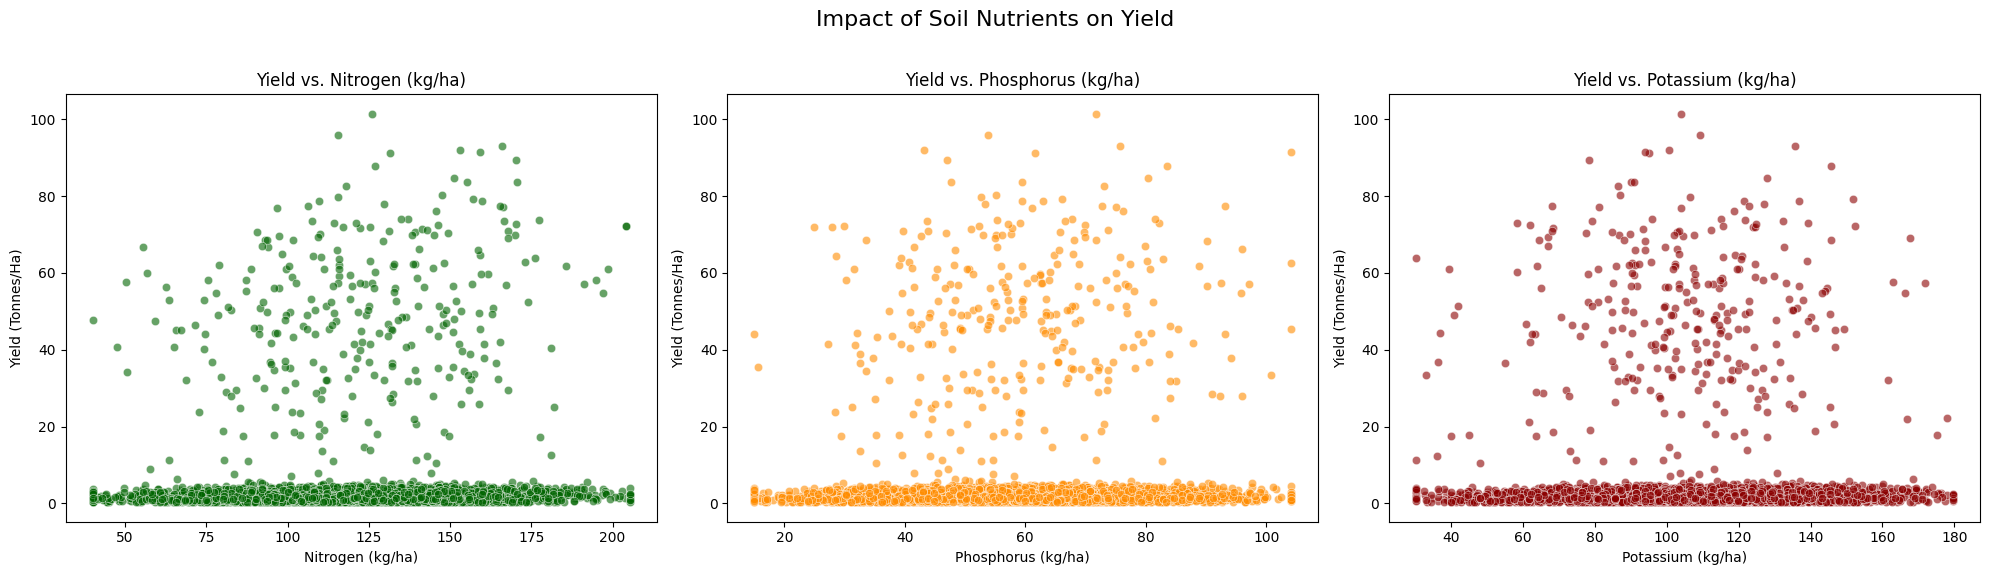

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Impact of Soil Nutrients on Yield', fontsize=16)

# Yield vs. Nitrogen_kg_ha
sns.scatterplot(x='Nitrogen_kg_ha', y='Yield_Tonnes_Ha', data=df_clean, ax=axes[0], alpha=0.6, color='darkgreen')
axes[0].set_title('Yield vs. Nitrogen (kg/ha)')
axes[0].set_xlabel('Nitrogen (kg/ha)')
axes[0].set_ylabel('Yield (Tonnes/Ha)')

# Yield vs. Phosphorus_kg_ha
sns.scatterplot(x='Phosphorus_kg_ha', y='Yield_Tonnes_Ha', data=df_clean, ax=axes[1], alpha=0.6, color='darkorange')
axes[1].set_title('Yield vs. Phosphorus (kg/ha)')
axes[1].set_xlabel('Phosphorus (kg/ha)')
axes[1].set_ylabel('Yield (Tonnes/Ha)')

# Yield vs. Potassium_kg_ha
sns.scatterplot(x='Potassium_kg_ha', y='Yield_Tonnes_Ha', data=df_clean, ax=axes[2], alpha=0.6, color='darkred')
axes[2].set_title('Yield vs. Potassium (kg/ha)')
axes[2].set_xlabel('Potassium (kg/ha)')
axes[2].set_ylabel('Yield (Tonnes/Ha)')

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.savefig('soil_nutrients_yield.png', dpi=120)
plt.show()

## Student-Designed Analysis 3: State-wise Profitability Analysis

This analysis focuses on comparing the profitability (`Profit_INR`) across different states. We will use a bar plot to visualize the average profit per state, which can highlight regional disparities and inform strategic decisions.

/tmp/ipykernel_2156/1573931913.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_profit.values, y=state_profit.index, palette='viridis')


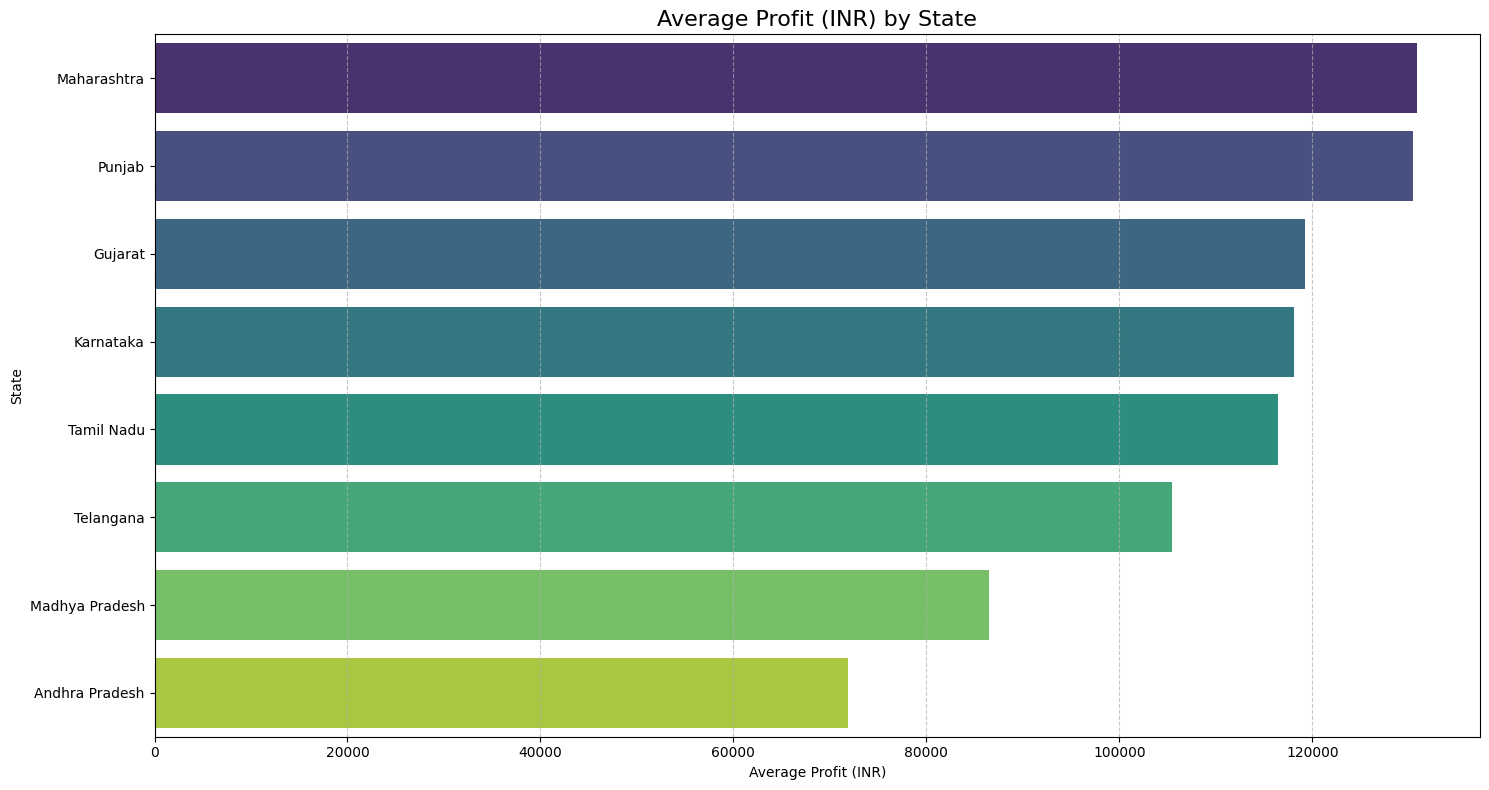

In [29]:
# Calculate average profit per state
state_profit = df_clean.groupby('State')['Profit_INR'].mean().sort_values(ascending=False)

plt.figure(figsize=(15, 8))
sns.barplot(x=state_profit.values, y=state_profit.index, palette='viridis')
plt.title('Average Profit (INR) by State', fontsize=16)
plt.xlabel('Average Profit (INR)')
plt.ylabel('State')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('state_profitability_analysis.png', dpi=120)
plt.show()

## Key Insights from the Analysis

This analysis unveiled several critical insights into agricultural performance:

*   **Data Quality is Foundational**: Missing values and outliers were significant, requiring imputation and capping, especially for `Profit_INR`, to ensure robust analysis.
*   **Performance Varies Greatly**: `Yield_Tonnes_Ha` and `Profit_INR` show skewed distributions, indicating a few high-performing farms. Performance differs significantly across various crops and states (e.g., Sugarcane/Rice, Maharashtra/Punjab often perform better).
*   **Environmental & Nutrient Impact**: Seasons, particularly `Kharif` rainfall, and adequate soil nutrients (`Nitrogen`, `Phosphorus`, `Potassium`) are strong determinants of yield.
*   **Profitability Disparities**: Clear differences in average profitability exist between states, suggesting the influence of regional factors.
*   **Correlation Patterns**: Positive relationships were observed between yield, profit, and rainfall, highlighting their interconnectedness in agricultural success.

## Evidence-Based Recommendations

Based on the analysis, here are key recommendations for optimizing agricultural practices:

*   **Improve Data Management**: Continue robust data collection and utilize imputation for missing values to maintain data quality.
*   **Strategic Crop & Season Management**: Encourage optimal crop selection and adapt practices to seasonal conditions to leverage environmental advantages.
*   **Enhance Soil Health**: Promote soil testing and balanced nutrient management (`N`, `P`, `K`) to boost yields.
*   **Investigate Successes & Challenges**: Study high-performing farms/regions to derive best practices and conduct localized research in lower-profit areas to address specific challenges.
*   **Integrated Approaches**: Implement holistic farm management strategies that consider interdependencies between yield, profit, and environmental factors like rainfall.

## Limitations of the Agricultural Dataset

Crucial limitations of this dataset include:

*   **Limited Scope**: The dataset's specific geographic and temporal boundaries restrict the generalizability of findings to other regions or time periods.
*   **Correlation, Not Causation**: The data identifies correlations but cannot establish direct causal relationships; experimental studies are needed for this.
*   **Granularity & Completeness**: The data resolution might be insufficient for detailed time-series analysis, and some key external variables (e.g., specific policies, market dynamics) may be missing, leading to an incomplete picture.
*   **Potential Inaccuracies**: The analysis assumes data accuracy, but potential errors in collection could bias results.
*   **Outlier Context**: While handled, extreme values might mask unique, valid cases without additional context.

## Final Conclusion

This analysis of agricultural data, following rigorous cleaning and outlier treatment, reveals critical insights into yield and profitability:

**Core Insights & Opportunities:**
*   **Performance Disparities**: Significant variations exist in yield and profit across different crops and states, highlighting opportunities for targeted interventions and learning from high-performers.
*   **Environmental & Nutrient Influence**: Seasonal patterns (especially rainfall in Kharif) and balanced soil nutrients (N, P, K) are strong drivers of yield, underscoring the importance of tailored practices.

**Actionable Recommendations:**
*   **Optimize & Adapt**: Encourage strategic crop selection and seasonal adaptation of farming practices.
*   **Targeted Support**: Implement soil management programs and investigate factors behind both high and low profitability at state and crop levels.

**Key Limitations:**
*   **Context Specificity**: Findings are geographically and temporally bound; direct causal links and external factors (e.g., policy, market) require further investigation.
*   **Data Granularity**: The current data may not capture all nuanced influences on performance.

In essence, this study provides a clear roadmap for enhancing agricultural productivity and profitability, emphasizing data-driven decisions while acknowledging the need for continuous research and context-specific application.